# Домашнее задание. Работа с пропусками и переменными

## 🎯 Цели задания

1. Научиться анализировать пропуски в данных.
2. Понять различные методы восстановления пропущенных значений.
3. Освоить методы масштабирования признаков.
4. Научиться кодировать категориальные переменные.
5. Понять важность валидации предобработки данных.
6. Работать с реальным датасетом Loan Prediction.



## 🧩 Задание

### Работайте с датасетом train.csv из архива Loan Prediction.



### Анализ пропусков

1. Для каждого столбца с пропусками рассчитайте % пропусков и определите тип переменной (числовая/категориальная).
2. На основе % пропусков и доменной логики составьте «матрицу решений»: какой метод применить к каждому столбцу.



shape: (614, 13)
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

             column  n_missing  proc_missing              type
6    Credit_History         50          8.14  порядковый (0/1)
3     Self_Employed         32          5.21    категориальный
4        LoanAmount         22          3.58          числовой
2        Dependents         15          2.44    категориальный
5  Loan_Amount_Term         14          2.28          числовой
0            Gender         13          2.12    категориальный
1           Married          3          0.49    категориальный

Строк с хотя бы одним пропуском: 134
Доля таких строк, %: 21.82


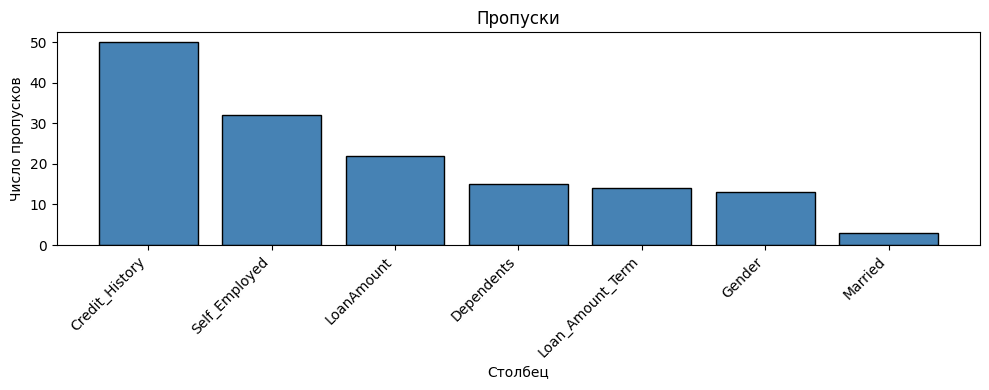


Матрица решений:
          column  proc_missing             type                                         method
  Credit_History          8.14 порядковый (0/1)                               мода + индикатор
   Self_Employed          5.21   категориальный                                           мода
      LoanAmount          3.58         числовой медиана + индикатор / модельное восстановление
      Dependents          2.44   категориальный                                           мода
Loan_Amount_Term          2.28         числовой                                           мода
          Gender          2.12   категориальный                                           мода
         Married          0.49   категориальный                                           мода


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder,
    TargetEncoder,
)
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv("Loan Prediction Problem Dataset/train_u6lujuX_CVtuZ9i.csv")

print("shape:", df.shape)
print(df.dtypes)
print()

# % пропусков и тип переменной
rows = []
for col in df.columns:
    n_miss = df[col].isna().sum() #isna проверяет, есть ли в каждом значении пропуск (NaN, None, NaT ...)
    if n_miss == 0:
        continue
    proc = 100 * n_miss / len(df) # процент пропуска для одного столбца
    if col == "Credit_History":
        vtype = "порядковый (0/1)"
    elif pd.api.types.is_numeric_dtype(df[col]):
        vtype = "числовой"
    else:
        vtype = "категориальный"
    rows.append(
        {
            "column": col,
            "n_missing": n_miss,
            "proc_missing": round(proc, 2),
            "type": vtype,
        }
    )

missing_table = pd.DataFrame(rows).sort_values("proc_missing", ascending=False)
print(missing_table)
print()
print("Строк с хотя бы одним пропуском:", int(df.isna().any(axis=1).sum()))
print(
    "Доля таких строк, %:",
    round(100 * df.isna().any(axis=1).mean(), 2),
)

# рисуем график пропусков
miss_counts = df.isna().sum()
miss_counts = miss_counts[miss_counts > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(miss_counts.index, miss_counts.values, color="steelblue", edgecolor="black")
ax.set_ylabel("Число пропусков")
ax.set_xlabel("Столбец")
ax.set_title("Пропуски")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# матрица решений — строится из missing_table
def suggest_method(row):
    col = row["column"]
    vtype = row["type"]
    if col == "LoanAmount":
        return "медиана + индикатор / модельное восстановление"
    if "порядковый" in vtype:
        return "мода + индикатор"
    if vtype == "числовой":
        # дискретный срок и т.п. — чаще мода, иначе медиана
        nunique = df[col].nunique(dropna=True)
        if nunique <= 15:
            return "мода"
        return "медиана"
    return "мода"


decision = missing_table.copy()
decision["method"] = decision.apply(suggest_method, axis=1)
print()
print("Матрица решений:")
print(decision[["column", "proc_missing", "type", "method"]].to_string(index=False))


### Восстановление пропусков

1. Примените метод на выбор к одному числовому признаку с пропусками (например, LoanAmount):
   - медиана + индикатор пропуска
   - модельное восстановление
2. Визуализируйте распределения до обработки и после каждого метода (гистограммы + ящики с усами).



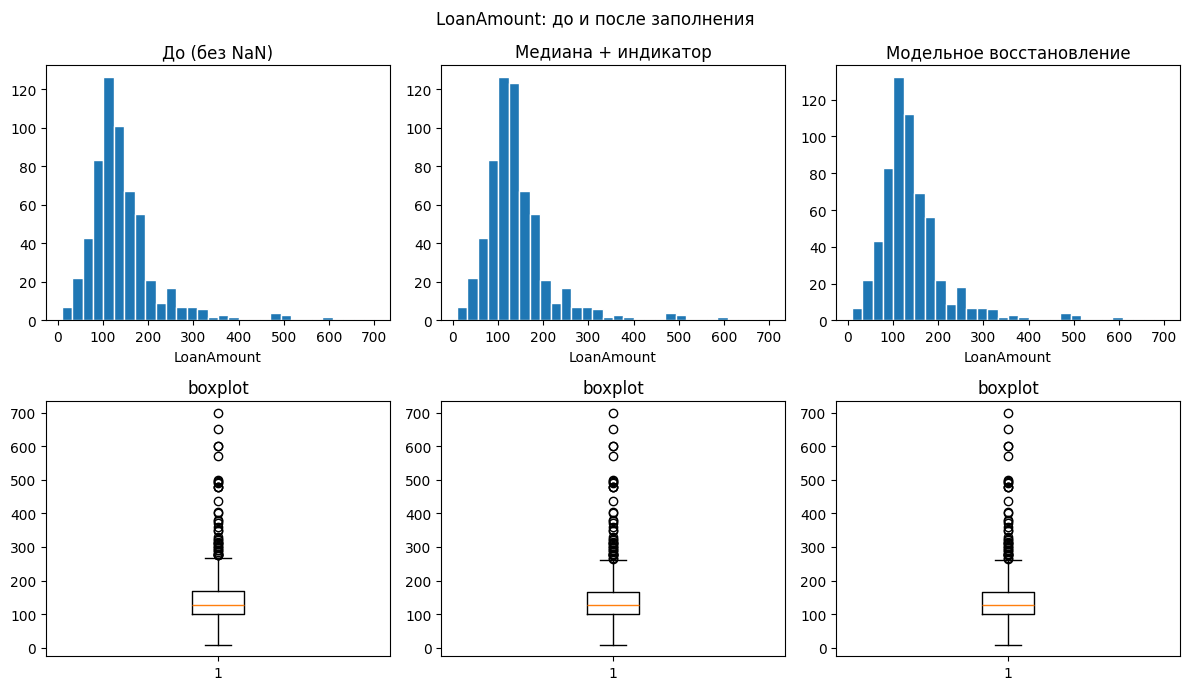

          raw  median   model
count  592.00  614.00  614.00
mean   146.41  145.75  146.25
std     85.59   84.11   84.29
min      9.00    9.00    9.00
25%    100.00  100.25  100.25
50%    128.00  128.00  128.00
75%    168.00  164.75  165.75
max    700.00  700.00  700.00


In [73]:
### LoanAmount: медиана + индикатор  и  модельное восстановление ###
loan_raw = df["LoanAmount"].copy()

df_med = df.copy()
df_med["LoanAmount_was_missing"] = df_med["LoanAmount"].isna().astype(int) # Ставим 0/1 в пропусках
median_val = df_med["LoanAmount"].median() # Считаем медиану, где есть значения
df_med["LoanAmount_filled"] = df_med["LoanAmount"].fillna(median_val) # Заполняем пропуски медианой

### модельное восстановление по доходам (простые числовые предикторы) ###
# Подготавливаем данные на основе доходов заемщика/созаемщика и выданых кредитов
df_mod = df.copy()
feat_cols = ["ApplicantIncome", "CoapplicantIncome"] 
X_help = df_mod[feat_cols].copy()
y_loan = df_mod["LoanAmount"]
mask_known = y_loan.notna() # строки с суммой
mask_miss = y_loan.isna() # строки без суммы

reg = LinearRegression()
reg.fit(X_help.loc[mask_known], y_loan.loc[mask_known]) # обучаем модель
pred = reg.predict(X_help.loc[mask_miss]) # предсказываем
pred = np.clip(pred, 0, None)

df_mod["LoanAmount_filled"] = y_loan.copy()
df_mod.loc[mask_miss, "LoanAmount_filled"] = pred # Заполняем пропуски предсказанным значением

### гистограммы + boxplot до / после ###
titles = [
    "До (без NaN)",
    "Медиана + индикатор",
    "Модельное восстановление",
]
series_list = [
    loan_raw.dropna(),
    df_med["LoanAmount_filled"],
    df_mod["LoanAmount_filled"],
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for i in range(3):
    axes[0, i].hist(series_list[i], bins=30, edgecolor="white")
    axes[0, i].set_title(titles[i])
    axes[0, i].set_xlabel("LoanAmount")
    axes[1, i].boxplot(series_list[i])
    axes[1, i].set_title("boxplot")
plt.suptitle("LoanAmount: до и после заполнения")
plt.tight_layout()
plt.show()

print(pd.DataFrame({
    "raw": loan_raw.dropna().describe(),
    "median": df_med["LoanAmount_filled"].describe(),
    "model": df_mod["LoanAmount_filled"].describe(),
}).round(2))



### Масштабирование

1. Выберите 2 числовых признака.
2. Примените к каждому признаку:
   - Минимаксную нормализацию
   - Z-нормализацию
3. Визуализируйте гистограммы до и после каждого преобразования. Сделайте вывод: какой метод лучше подошёл для каждого типа распределения.



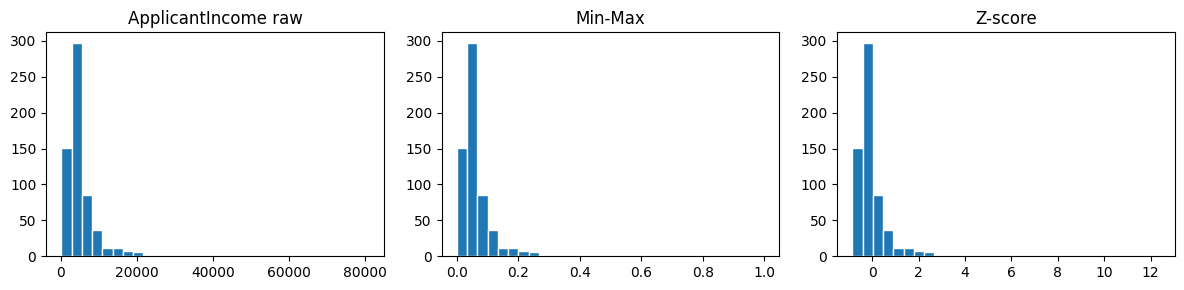

ApplicantIncome : skew = 6.54 | min/max = 150 / 81000


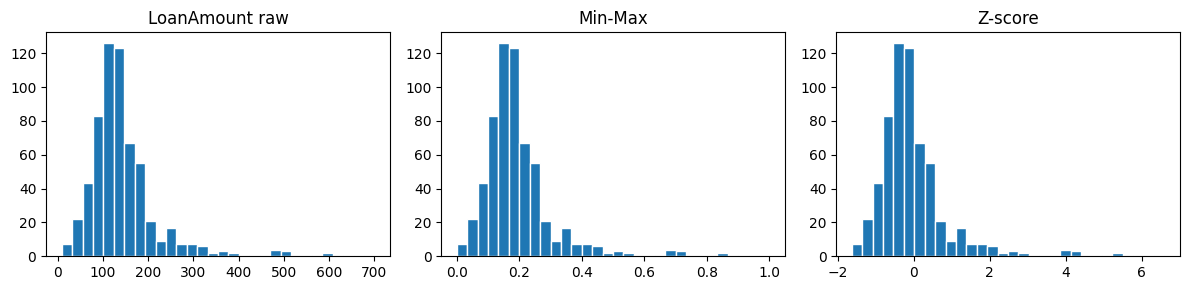

LoanAmount : skew = 2.743 | min/max = 9.0 / 700.0

Вывод: Min-Max и Z-score не меняют форму распределения, только шкалу. При сильной скошенности и выбросах (большой |skew|) для линейных моделей обычно предпочтительнее Z-score; Min-Max чувствителен к экстремумам.


In [74]:
# два числовых признака
scale_df = df.copy()
scale_df["LoanAmount"] = scale_df["LoanAmount"].fillna(scale_df["LoanAmount"].median()) # Заполняем медианой пустые значения

feats = ["ApplicantIncome", "LoanAmount"]

mm = MinMaxScaler() # (x − min) / (max − min)
zz = StandardScaler() # (x − mean) / std

# fit — посчитать min и max по каждому из двух столбцов;
# transform — применить формулу ко всем строкам.
mm_vals = mm.fit_transform(scale_df[feats])
zz_vals = zz.fit_transform(scale_df[feats])

# Заносим значения в таблицу
scale_df["ApplicantIncome_mm"] = mm_vals[:, 0]
scale_df["LoanAmount_mm"] = mm_vals[:, 1]
scale_df["ApplicantIncome_z"] = zz_vals[:, 0]
scale_df["LoanAmount_z"] = zz_vals[:, 1]

for feat in feats:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    axes[0].hist(scale_df[feat], bins=30, edgecolor="white")
    axes[0].set_title(feat + " raw")
    axes[1].hist(scale_df[feat + "_mm"], bins=30, edgecolor="white")
    axes[1].set_title("Min-Max")
    axes[2].hist(scale_df[feat + "_z"], bins=30, edgecolor="white")
    axes[2].set_title("Z-score")
    plt.tight_layout()
    plt.show()

    skew = scale_df[feat].skew()
    print(
        feat,
        ": skew =",
        round(skew, 3),
        "| min/max =",
        scale_df[feat].min(),
        "/",
        scale_df[feat].max(),
    )

print()
print(
    "Вывод: Min-Max и Z-score не меняют форму распределения, только шкалу. "
    "При сильной скошенности и выбросах (большой |skew|) для линейных моделей "
    "обычно предпочтительнее Z-score; Min-Max чувствителен к экстремумам."
)



### Кодирование категориальных переменных

1. Выделите 2 категориальных признака: один порядковый (например, Credit_History), второй номинальный (например, Property_Area).
2. Примените к ним разные методы:
   - для порядкового: OrdinalEncoder (порядковое кодирование)
   - для номинального: OneHotEncoder + сравнение с TargetEncoder (с корректной кросс-валидацией)
3. Проверьте размерность датасета до и после кодирования. Оцените рост числа признаков.



In [ ]:
# Берем число иждевенцев для более логичного анализа, так как в Credit History только 0 и 1 и нет смысла их разбивать на категории.
enc = df.copy()
enc["target"] = (enc["Loan_Status"] == "Y").astype(int) # 1 - кредит одобрен, 0 - крдеит не одобрен

# Dependents — порядковый: OrdinalEncoder (пропуски = мода)
# 0 < 1 < 2 < 3+ (число иждивенцев)
dep_mode = enc["Dependents"].mode().iloc[0] # мода
enc["Dependents"] = enc["Dependents"].fillna(dep_mode) # Заполянем модой

ord_enc = OrdinalEncoder(categories=[["0", "1", "2", "3+"]])
enc["Dependents_ord"] = ord_enc.fit_transform(enc[["Dependents"]]) # запомнить категории и заменить значения на их коды

# Property_Area — номинальный: OneHot
# Создаем матриц (создаем колонки) для всех категорий, и заполняем их нулями и единицами
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore") # игнорируем пустоты
ohe_mat = ohe.fit_transform(enc[["Property_Area"]])
ohe_cols = ["PA_" + str(c) for c in ohe.categories_[0]]
ohe_df = pd.DataFrame(ohe_mat, columns=ohe_cols, index=enc.index)

print(ohe_df)

# Property_Area — TargetEncoder с CV (без утечки в fit_transform)
# Категорию кодируют средним target (доля одобрений в этом районе), со сглаживанием.
te = TargetEncoder(target_type="binary", smooth="auto", cv=5, random_state=42)
# Обучаем, ставим для каждого района процент одобрений
enc["Property_Area_te"] = te.fit_transform(enc[["Property_Area"]], enc["target"])

# ord_ohe = иждивенцы + «флажки» районов;
# ord_te = иждивенцы + «рейтинг района по одобрениям».
ord_ohe = pd.concat([enc[["Dependents_ord"]], ohe_df], axis=1)
ord_te = enc[["Dependents_ord", "Property_Area_te"]]

print("До кодирования (2 признака):", enc[["Dependents", "Property_Area"]].shape)
print("После Ordinal + OneHot:", ord_ohe.shape)
print("После Ordinal + TargetEncoder:", ord_te.shape)
print(
    "Прирост признаков OneHot по Property_Area:",
    ohe_df.shape[1],
    "(категории:",
    list(ohe.categories_[0]),
    ")",
)
print("TargetEncoder: 1 столбец на признак, размерность не растёт")
print()

# Доля одобрений (средний target) по иждивенцам и районам
rate_dep = enc.groupby("Dependents")["target"].mean().sort_values(ascending=False)
rate_area = enc.groupby("Property_Area")["target"].mean().sort_values(ascending=False)

print("Средний target (доля одобрений) по Dependents:")
print(rate_dep.round(3))
print()
print("Средний target (доля одобрений) по Property_Area:")
print(rate_area.round(3))
print()

# Выводы — из данных, без захардкоженных процентов
best_dep = rate_dep.index[0]
worst_dep = rate_dep.index[-1]
best_area = rate_area.index[0]
worst_area = rate_area.index[-1]

print("Выводы по частоте одобрения:")
print(
    f"- По иждивенцам (Dependents) чаще всего одобряют при значении "
    f"'{best_dep}' (доля {rate_dep.iloc[0]:.1%}), "
    f"реже всего — при '{worst_dep}' (доля {rate_dep.iloc[-1]:.1%})."
)
print(
    f"- По районам (Property_Area) чаще всего одобряют в '{best_area}' "
    f"(доля {rate_area.iloc[0]:.1%}), "
    f"реже всего — в '{worst_area}' (доля {rate_area.iloc[-1]:.1%})."
)
print(
    "- Это описательная статистика по train, не причинно-следственный вывод: "
    "на решение влияют и другие признаки (доход, Credit_History и т.д.)."
)


     PA_Rural  PA_Semiurban  PA_Urban
0         0.0           0.0       1.0
1         1.0           0.0       0.0
2         0.0           0.0       1.0
3         0.0           0.0       1.0
4         0.0           0.0       1.0
..        ...           ...       ...
609       1.0           0.0       0.0
610       1.0           0.0       0.0
611       0.0           0.0       1.0
612       0.0           0.0       1.0
613       0.0           1.0       0.0

[614 rows x 3 columns]
До кодирования (2 признака): (614, 2)
После Ordinal + OneHot: (614, 4)
После Ordinal + TargetEncoder: (614, 2)
Прирост признаков OneHot по Property_Area: 3 (категории: ['Rural', 'Semiurban', 'Urban'] )
TargetEncoder: 1 столбец на признак, размерность не растёт

Средний target (доля одобрений) по Dependents:
Dependents
2     0.752
0     0.686
1     0.647
3+    0.647
Name: target, dtype: float64

Средний target (доля одобрений) по Property_Area:
Property_Area
Semiurban    0.768
Urban        0.658
Rural        0.615
N

### Валидация предобработки

1. Обучите логистическую регрессию на двух версиях данных:
   - Версия 1: только удаление строк с пропусками
   - Версия 2: датасет с обработанными признаками
2. Сравните ROC-AUC на валидационной выборке. Сделайте вывод о влиянии качества предобработки на метрику.



In [76]:
work = df.copy()
work["target"] = (work["Loan_Status"] == "Y").astype(int) # Столбец для результата

feature_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area",
]
cat_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
]
num_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
]

X = work[feature_cols] # Входящие признаки
y = work["target"] # Ответы

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Версия 1: только dropna ---
# К признакам временно приклеиваем y, чтобы при dropna не «потерять» соответствие строк X и y.
tr = X_train.copy()
tr["y"] = y_train.values
va = X_val.copy()
va["y"] = y_val.values

tr = tr.dropna()
va = va.dropna()

# Снова разделяем: признаки отдельно, target отдел
y_tr1 = tr["y"].astype(int)
y_va1 = va["y"].astype(int)
tr = tr.drop(columns=["y"])
va = va.drop(columns=["y"])

# Конвейер: сначала подготовка признаков, потом модель
pipe1 = Pipeline(
    steps=[
        (
            "prep",  # шаг 1: подготовка
            ColumnTransformer(  # разным столбцам — разная обработка
                [
                    # числа это Z-score (среднее 0, разброс 1)
                    ("num", StandardScaler(), num_cols),
                    (
                        "cat",
                        # категории это столбцы 0/1; unknown — не падать на новых метках
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                        cat_cols,
                    ),
                ]
            ),
        ),
        # шаг 2: логистическая регрессия (вероятность одобрения)
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)
# обучить prep + модель на train
pipe1.fit(tr, y_tr1)
# вероятность класса 1 на val - ROC-AUC (качество ранжирования)
# Модель для каждой строки va выдаёт две вероятности:
auc1 = roc_auc_score(y_va1, pipe1.predict_proba(va)[:, 1])



# --- Версия 2: заполнение пропусков + флаг + кодирование (строки не удаляем) ---
def impute(X_tr, X_va):
    
    X_tr = X_tr.copy()
    X_va = X_va.copy()

    # Новый столбец-флаг: 1 = сумма кредита изначально была пустой (делаем ДО fillna)
    X_tr["LoanAmount_miss"] = X_tr["LoanAmount"].isna().astype(int)
    X_va["LoanAmount_miss"] = X_va["LoanAmount"].isna().astype(int)

    # числовые/бинарные пропуски: статистика только с train
    for col in ["LoanAmount", "Loan_Amount_Term", "Credit_History"]:
        if col == "Credit_History":
            fill = X_tr[col].mode().iloc[0]  # самое частое значение
        else:
            fill = X_tr[col].median()  # медиана (устойчива к выбросам)
        X_tr[col] = X_tr[col].fillna(fill)
        X_va[col] = X_va[col].fillna(fill)  # val — той же величиной с train

    # для всех категориальных значений ставим моду
    for col in cat_cols:
        mode_val = X_tr[col].mode().iloc[0]
        X_tr[col] = X_tr[col].fillna(mode_val)
        X_va[col] = X_va[col].fillna(mode_val)

    return X_tr, X_va  # таблицы без NaN (по этим столбцам)


# применяем заполнение к train и val
X_tr2, X_va2 = impute(X_train, X_val)

num_cols2 = num_cols + ["LoanAmount_miss"]  # числа + флаг пропуска
ord_cols = ["Credit_History"]  # порядковый 0/1
cat_cols2 = list(cat_cols)  # категории для One-Hot
# Credit_History убираем из scaler — его обработает OrdinalEncoder
num_only = [c for c in num_cols2 if c != "Credit_History"]

# конвейер V2: подготовка для логистической регрессии
pipe2 = Pipeline(
    steps=[
        (
            "prep",  # шаг 1: подготовка
            ColumnTransformer(  # разным столбцам — разная обработка
                [
                    # числа к одному виду, близкие значения(+ флаг): Z-score
                    ("num", StandardScaler(), num_only),
                    (
                        "ord",
                        # кредитная история: 0 и 1 с явным порядком
                        OrdinalEncoder(categories=[[0.0, 1.0]]),
                        ord_cols,
                    ),
                    (
                        "cat",
                        # категории = 0/1; unknown — не падать на новых метках
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                        cat_cols2,
                    ),
                ]
            ),
        ),
        # шаг 2: вероятность одобрения кредита
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

# обучить на заполненном train (все строки)
pipe2.fit(X_tr2, y_train)
# качество на val: ROC-AUC по вероятности класса 1
auc2 = roc_auc_score(y_val, pipe2.predict_proba(X_va2)[:, 1])


# --- ИТОГИ ---
compare = pd.DataFrame(
    [
        {
            "version": "V1 dropna",
            "n_train": len(tr),
            "n_val": len(va),
            "ROC_AUC": round(auc1, 4),
        },
        {
            "version": "V2 impute+encode+scale",
            "n_train": len(X_tr2),
            "n_val": len(X_va2),
            "ROC_AUC": round(auc2, 4),
        },
    ]
)
print(compare)
print()
print(
    "V1 учится и проверяется на меньшем числе строк (после удаления пропусков)."
    "V2 сохраняет все объекты за счёт заполнения."
    "ROC-AUC у V1 на своём val чуть выше, но val разный; для работы со всеми заявками предпочтительнее V2."
)


                  version  n_train  n_val  ROC_AUC
0               V1 dropna      381     99   0.8720
1  V2 impute+encode+scale      491    123   0.8647

V1 учится и проверяется на меньшем числе строк (после удаления пропусков).V2 сохраняет все объекты за счёт заполнения.ROC-AUC у V1 на своём val чуть выше, но val разный; для работы со всеми заявками предпочтительнее V2.


## 📝 Выводы

1. **Пропуски.** Лучший баланс простоты и сохранения информации — заполнение типичным значением (медиана / мода) **плюс индикатор пропуска** для важных полей. Модельное восстановление альтернатива для числовых, но сложнее. Полный `dropna` сильно сокращает выборку.

2. **Масштабирование.** Min-Max и Z-score не меняют форму распределения, только шкалу. При скошенности и выбросах для логистической регрессии обычно уместнее Z-score; Min-Max чувствителен к экстремальным min/max.

3. **Утечка target.** Наиболее критичен **Target Encoding** без кросс-валидации (среднее target «подсматривает» ответ). Избежали: `TargetEncoder(..., cv=5)` и статистики импутации/скейла считаются **только на train**.
